In [1]:
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense

In [2]:
# 데이터 불러오기
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# 데이터 정규화
x_train = x_train / 255.0
x_test = x_test / 255.0

# CNN 입력 형태 (28,28) => (28,28,1) [1이면 흑백, 3이면 컬러 (컬러가 3인 이유는 RGB 3개라서)]

x_train = x_train.reshape(-1,28,28,1)  # (60000, 28, 28, 1)
x_test = x_test.reshape(-1,28,28,1)  # (10000, 28, 28, 1)

print(x_train.shape)
print(x_test.shape)

# CNN 모델
model = Sequential([
    Input(shape=(28,28,1)),  # CNN 입력형태를 적어주면 됨
    Conv2D(32, (3,3), activation="relu"),  # 3X3 크기씩 보면서 32개의 특징을 찾겠다는 의미 
    MaxPooling2D((2,2)),  # 전체적인 이미지 크기를 줄이는 층인데 ,Conv2D에서 특징을 찾았다면 가장 큰 특징만 남겨둠 => 중요한 특징은 유지, 계산량은 감소
    Flatten(),  # 2차원, 3차원 배열을 1차원 배열로 만들어줌 => 2차원/3차원 이미지 특징을 Dense 층이 계산할 수 있도록 1차원으로 바꿔주는 과정
    Dense(128,activation="relu"),
    Dense(10,activation="softmax")
])

model.summary()

# 콤파일
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# 학습
history = model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=23,
    validation_split=0.2
)

# 평가
loss , accuracy = model.evaluate(x_test,y_test)
print("정확도", accuracy)  # 정확도 0.984499990940094 약 98%의 정확도

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1)
(10000, 28, 28, 1)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       692,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 693,962 (2.65 MB)

 Trainable params: 693,962 (2.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.9558 - loss: 0.1502 - val_accuracy: 0.9762 - val_loss: 0.0743
Epoch 2/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9839 - loss: 0.0530 - val_accuracy: 0.9746 - val_loss: 0.0803
Epoch 3/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9898 - loss: 0.0314 - val_accuracy: 0.9826 - val_loss: 0.0580
Epoch 4/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9936 - loss: 0.0204 - val_accuracy: 0.9834 - val_loss: 0.0580
Epoch 5/5
2087/2087 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9952 - loss: 0.0142 - val_accuracy: 0.9854 - val_loss: 0.0611
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9837 - loss: 0.0551
정확도 0.9836999773979187


In [3]:
model.save("mnist_cnn.keras")

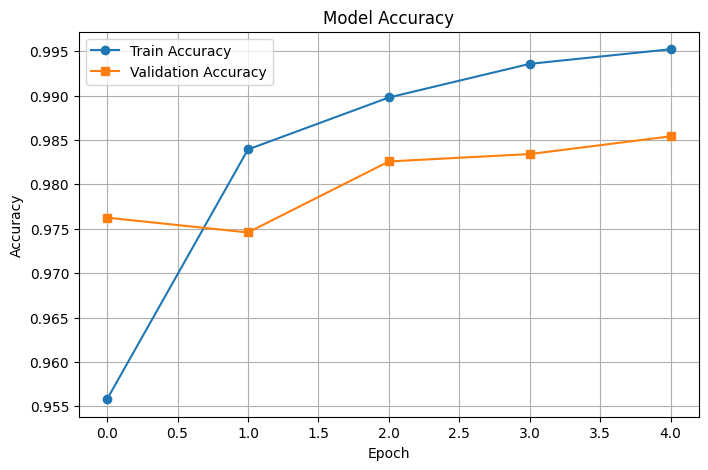

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], marker="o", label="Train Accuracy")
plt.plot(history.history["val_accuracy"], marker="s", label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()

plt.show()

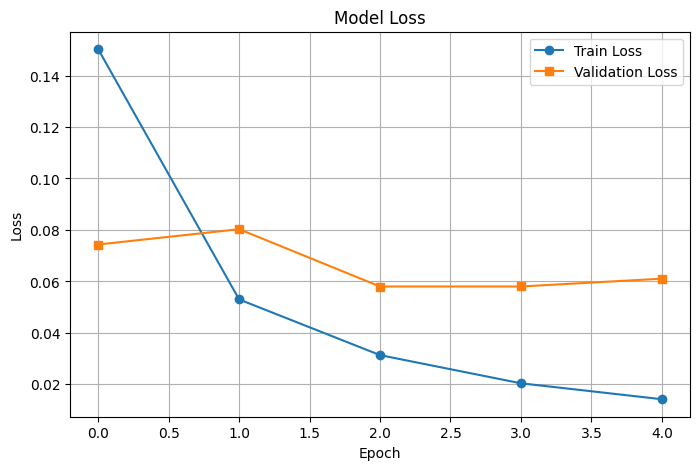

In [5]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], marker="o", label="Train Loss")
plt.plot(history.history["val_loss"], marker="s", label="Validation Loss")

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.show()

In [7]:
!pip -q install gradio

import gradio as gr
print(gr.__version__)
import gradio as gr
import numpy as np
from PIL import Image
from tensorflow.keras.models import load_model

model = load_model("mnist_cnn.keras")


# ------------------------------
# 예측 함수
# ------------------------------

def predict(data):

    if data is None:
        return {}, None

    # Gradio5.x
    if isinstance(data, dict):

        img = data.get("composite", None)

        if img is None:
            return {}, None

    else:
        img = data

    # 흑백
    from PIL import Image

    img = Image.fromarray(img)
    img = img.convert("L")

    # 28x28
    img28 = img.resize((28,28))

    # MNIST 형태
    img28 = Image.fromarray(
        255 - np.array(img28)
    )

    # 정규화
    x = np.array(img28).astype("float32")/255.0

    x = x.reshape(1,28,28,1)

    pred = model.predict(x,verbose=0)[0]

    result = {
        str(i): float(pred[i])
        for i in range(10)
    }

    return result, img28


# ------------------------------
# UI
# ------------------------------

with gr.Blocks() as demo:

    gr.Markdown("# ✍️ CNN 손글씨 숫자 인식")

    gr.Markdown(
        "숫자를 그리고 마우스를 놓으면 자동으로 예측합니다."
    )

    with gr.Row():

        sketch = gr.Sketchpad(
            height=280,
            width=280
        )

        preview = gr.Image(
            label="28×28 CNN 입력",
            interactive=False
        )

    label = gr.Label(
        num_top_classes=3,
        label="예측 결과"
    )

    sketch.change(
        fn=predict,
        inputs=sketch,
        outputs=[
            label,
            preview
        ]
    )

demo.launch(debug=True)

6.19.0
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/06/30 23:41:43 [W] [service.go:132] login to server failed: session shutdown


<IPython.core.display.Javascript object>

Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> None
